## Importing Required Libraries

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

In [23]:
#seting random seeds for reproducibility
torch.manual_seed(4)

## Importing Data

In [24]:
df = pd.read_csv('fmnist_small.csv')

In [25]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


## Viewing the data

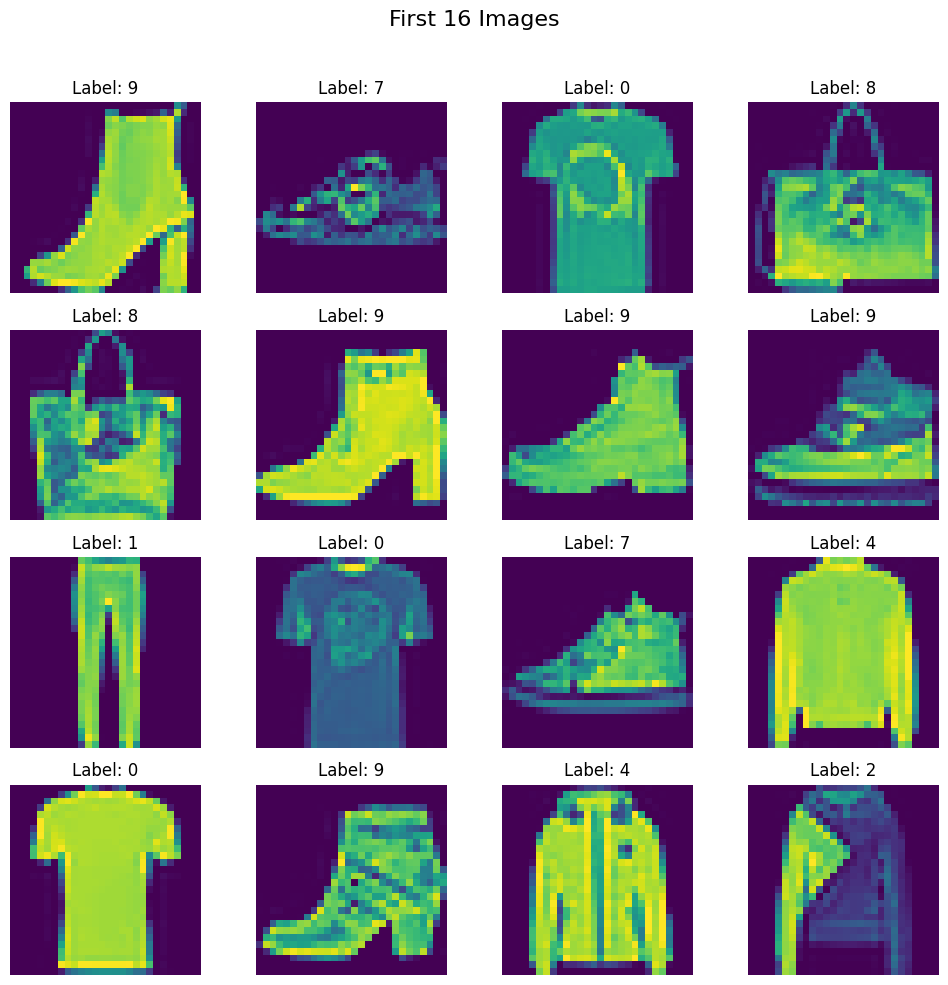

In [26]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


## EDA

## 1.Train test split

In [27]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [28]:
X_test, X_train, y_test, y_train = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 2.Scaling the features

In [29]:
X_train = X_train/255.0
x_test = X_test/255.0

## Create CustomDataset Class

In [30]:
# create CustomDataset Class
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self, index):

    return self.features[index], self.labels[index]



In [31]:
# create train datser object
train_dataset = CustomDataset(
    X_train,
    y_train
)

In [32]:
# create train datser object
test_dataset = CustomDataset(
    X_test,
    y_test
)

## Creating train and test loader

In [33]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


## Define NN Class

In [34]:
# define NN class

class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):

    return self.model(x)

## Setting Learning rate and epochs

In [35]:
epochs = 100
learning_rate = 0.1

In [36]:
#instatiate the model
model = MyNN(X_train.shape[1])

#loss function
loss_function = nn.CrossEntropyLoss()

#optitmizer
optimizer = optim.SGD(model.parameters(), lr = learning_rate)

In [37]:
len(train_loader)

38

In [38]:
#traing loop
for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:

        #forward pass
        outputs = model(batch_features)

        #calculating loss
        loss = loss_function(outputs, batch_labels)

        #clearing Gradient
        optimizer.zero_grad()
        
        #backpass
        loss.backward()

        #update grads 
        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()

        avg_loss = total_epoch_loss/len(train_loader)
        print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 0.06109135401876349
Epoch: 1 , Loss: 0.12232218918047454
Epoch: 1 , Loss: 0.18209533942373177
Epoch: 1 , Loss: 0.2421890748174567
Epoch: 1 , Loss: 0.3015459524957757
Epoch: 1 , Loss: 0.36111199855804443
Epoch: 1 , Loss: 0.4214539967085186
Epoch: 1 , Loss: 0.48131225611034195
Epoch: 1 , Loss: 0.5410929541838797
Epoch: 1 , Loss: 0.5993574104811016
Epoch: 1 , Loss: 0.658963397929543
Epoch: 1 , Loss: 0.7183035800331518
Epoch: 1 , Loss: 0.7777034483457866
Epoch: 1 , Loss: 0.8363146656437924
Epoch: 1 , Loss: 0.8935095260017797
Epoch: 1 , Loss: 0.9511475939499704
Epoch: 1 , Loss: 1.009878208762721
Epoch: 1 , Loss: 1.0659797819037187
Epoch: 1 , Loss: 1.1232250238719739
Epoch: 1 , Loss: 1.1776714889626754
Epoch: 1 , Loss: 1.2353390768954629
Epoch: 1 , Loss: 1.2916745700334247
Epoch: 1 , Loss: 1.345750971844322
Epoch: 1 , Loss: 1.3997449937619661
Epoch: 1 , Loss: 1.4523671677238064
Epoch: 1 , Loss: 1.505649027071501
Epoch: 1 , Loss: 1.5553555708182485
Epoch: 1 , Loss: 1.60814715

## Model Evaluation

In [39]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [40]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                   Param #
MyNN                                     --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       100,480
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       8,256
│    └─ReLU: 2-4                         --
│    └─Linear: 2-5                       650
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0

In [41]:
correct = 0
total = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        batch_features = batch_features
        batch_labels = batch_labels

        outputs = model(batch_features)
        _, predicted = torch.max(outputs, dim=1)

        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy = {accuracy:.2f}%")

Accuracy = 77.25%


In [42]:
len(test_loader)

150